# 07 · Metals — geometries, isomers, chelates, TS, binding modes

A metal centre becomes a UFF-typeable **carbon surrogate** (bonds stripped), held by distance + angle constraints for the chosen polyhedron, then restored — plain RDKit, no xtb. `rx.metal(smiles, geometry)` enumerates the distinct **coordination isomers** as an `IsomerSet` to pick from.

**Rendering note.** xyzrender detects ordinary bonds (including metal–donor coordination) from the geometry on its own — we only name the *special* ones: **non-covalent contacts** (H-bonds, chalcogen, cation-π) via `nci_bonds=[(i, j)]` (dotted), and **genuine forming/breaking TS bonds** via `ts_bonds=[(i, j)]` (dashed). Distances/angles are labelled with `labels=["i j d"]` / `"i j k a"`. xyzrender is 1-indexed, so atom indices are passed `+1`.

In [35]:
import tempfile
import numpy as np
import rxembed as rx
import xyzrender
from rdkit import RDLogger
from rdkit.Chem import rdMolTransforms as T
from rxembed.constraints.metal import metal_indices
from rxembed.embed.dispatch import _xyz_to_mol

RDLogger.DisableLog("rdApp.*")
rx.set_verbose("INFO")


def xyz(ens):
    return ens.lowest(1).dump(tempfile.mktemp(suffix=".xyz"))  # 1 conformer -> a path xyzrender reads


def mxyz(ens):
    return ens.dump(tempfile.mktemp(suffix=".xyz"))  # 1 conformer -> a path xyzrender reads

## Coordination isomers — the permutations

Square-planar MA₂B₂ → **cis / trans**; octahedral MA₃B₃ → **mer / fac**. `.summary()` tags each with its per-vertex ligand arrangement (the unambiguous identity); `.select(...)` picks one to conf-search.

In [36]:
print("square-planar Pd (cis/trans):")
rx.metal("CCCN[Pd](Cl)(Cl)NCCC", "square_planar").summary()
print("\noctahedral Co(NH3)3Cl3 (mer/fac):")
rx.metal("N[Co](N)(N)(Cl)(Cl)Cl", "octahedral").summary()

square-planar Pd (cis/trans):
  [0] square_planar      cis     N3 Cl5 Cl6 N7
  [1] square_planar      trans   N3 Cl6 N7 Cl5

octahedral Co(NH3)3Cl3 (mer/fac):
  [0] octahedral         mer     N0 N2 N3 Cl4 Cl5 Cl6
  [1] octahedral         fac     N0 Cl4 N3 Cl5 N2 Cl6


[Isomer(mol=<rdkit.Chem.rdchem.Mol object at 0x7f10ff69aa70>, cons=Constraints(distances={(0, 1): (1.7229999999999999, 1.823), (1, 2): (1.7229999999999999, 1.823), (1, 3): (1.7229999999999999, 1.823), (1, 4): (2.0020000000000007, 2.1020000000000003), (1, 5): (2.0020000000000007, 2.1020000000000003), (1, 6): (2.0020000000000007, 2.1020000000000003)}, angles={(0, 1, 2): (172.0, 180.0), (3, 1, 4): (172.0, 180.0), (5, 1, 6): (172.0, 180.0), (0, 1, 3): (82.0, 98.0), (2, 1, 5): (82.0, 98.0), (4, 1, 6): (82.0, 98.0)}, planes=[], frozen=set(), contacts=(frozenset(), frozenset())), metal=1, donors=[0, 2, 3, 4, 5, 6], real_z=27, label='mer', geometry='octahedral', vertices=[0, 2, 3, 4, 5, 6], extra=[], stereo_ref=None),
 Isomer(mol=<rdkit.Chem.rdchem.Mol object at 0x7f10ff69a750>, cons=Constraints(distances={(0, 1): (1.7229999999999999, 1.823), (1, 4): (2.0020000000000007, 2.1020000000000003), (1, 3): (1.7229999999999999, 1.823), (1, 5): (2.0020000000000007, 2.1020000000000003), (1, 2): (1.72299

The **fac** Co isomer: the coordination sphere drawn as dotted dative bonds (`nci_bonds`) makes the 3 N / 3 Cl faces obvious; element labels via `idx='s'`.

rxembed | embed[octahedral fac]: 14 seeds
rxembed | mc: preset='rapid' on a constrained system under-samples (pose-mode is rotor-only); 'ensemble' (the default) is recommended for a constrained run
rxembed | mc: +1 (openconf 'rapid', pose-constrained around seeds; total 15)
rxembed | prune[rmsd]: 15 -> 2  (merged 13 near-duplicates; see .duplicates())


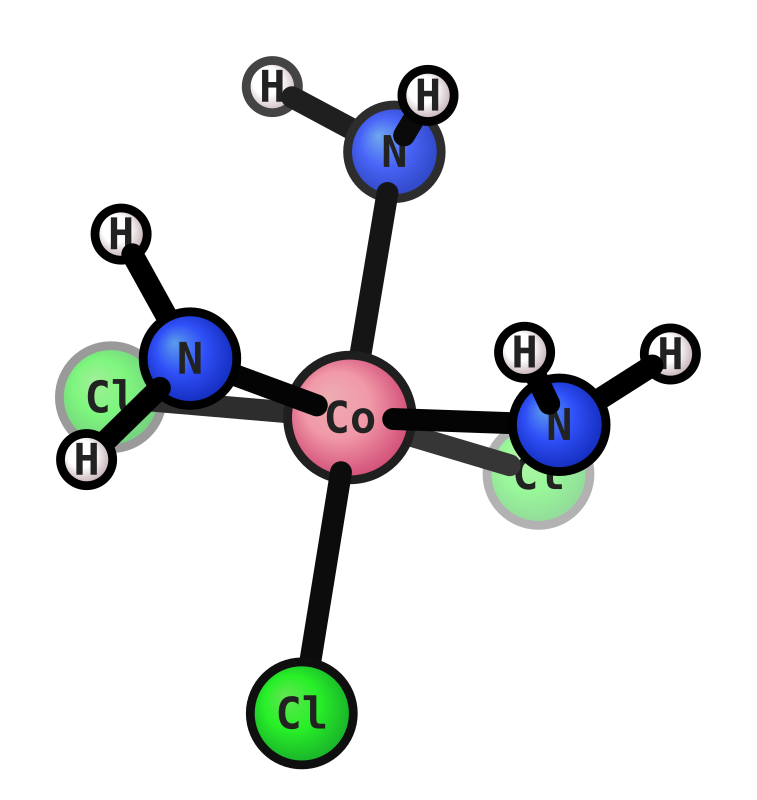

In [37]:
co = rx.metal("N[Co](N)(N)(Cl)(Cl)Cl", "octahedral").select(label="fac")
ens = rx.embed(co).mc(preset="rapid").prune()
p = xyz(ens)
xyzrender.render(p, no_hy=True, idx="s")  # coordination bonds auto-detect from the geometry

The **trans** Pd isomer — the two Cl sit ~180° across the metal (labelled Cl–Pd–Cl angle).

rxembed | embed[square_planar trans]: 40 seeds
rxembed | mc: preset='rapid' on a constrained system under-samples (pose-mode is rotor-only); 'ensemble' (the default) is recommended for a constrained run
rxembed | mc: +5 (openconf 'rapid', pose-constrained around seeds; total 45)
rxembed | prune[rmsd]: 45 -> 42  (merged 3 near-duplicates; see .duplicates())


42 conformers | Cl-Pd-Cl = 172° (trans)


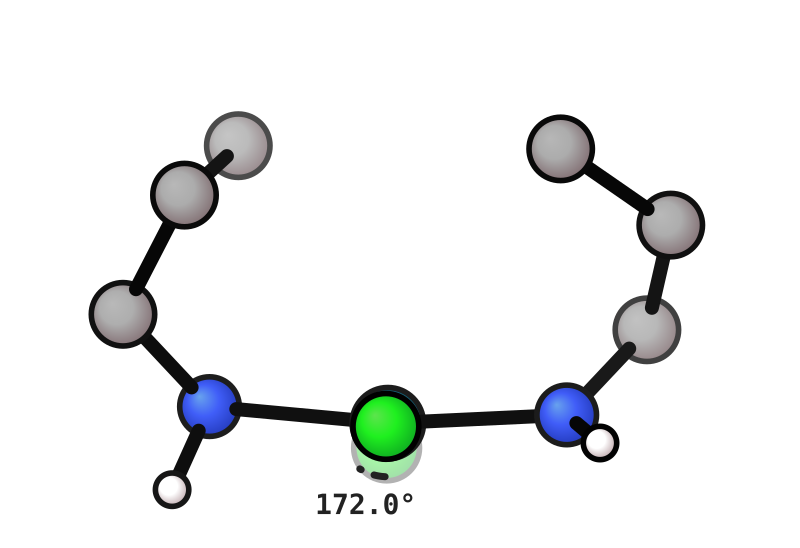

In [39]:
trans = rx.metal("CCCN[Pd](Cl)(Cl)NCCC", "square_planar").select(label="trans")
ens = rx.embed(trans).mc(preset="rapid").prune()
cl = [d for d in trans.donors if ens.mol.GetAtomWithIdx(d).GetSymbol() == "Cl"]
print(f"{len(ens)} conformers | Cl-Pd-Cl = {ens.measure((cl[0], trans.metal, cl[1]))['mean']:.0f}° (trans)")
p = xyz(ens)
xyzrender.render(
    p, no_hy=True, labels=[f"{cl[0] + 1} {trans.metal + 1} {cl[1] + 1} a"]
)  # label the trans Cl-Pd-Cl angle

## Across coordination geometries

One surface spans the polyhedra — linear, tetrahedral, square-planar, octahedral (and trigonal-bipyramidal / square-pyramidal for 5-coordinate).

In [40]:
for g, smi in {
    "linear": "[Cl][Au][Cl]",
    "tetrahedral": "Cl[Zn](Cl)(Cl)Cl",
    "square_planar": "CCCN[Pd](Cl)(Cl)NCCC",
    "octahedral": "N[Co](N)(N)(Cl)(Cl)Cl",
}.items():
    isos = rx.metal(smi, g)
    print(f"  {g:14s}: {len(isos)} isomer(s) {[i.label for i in isos]}")

  linear        : 1 isomer(s) ['']
  tetrahedral   : 1 isomer(s) ['']
  square_planar : 2 isomer(s) ['cis', 'trans']
  octahedral    : 2 isomer(s) ['mer', 'fac']


## Chelating ligands — bidentate

A chelate's donors sit on one ligand fragment; rxembed detects same-fragment donors and widens their L–M–L window (a rigid backbone bite is distorted off the ideal) while still separating cis from trans. Ethylenediamine on Pd (a 5-membered chelate ring, N–Pd–N bite ~82°) + two chloride:

rxembed | embed[square_planar cis]: 10 seeds
rxembed | mc: preset='rapid' on a constrained system under-samples (pose-mode is rotor-only); 'ensemble' (the default) is recommended for a constrained run


rxembed | mc: +1 (openconf 'rapid', pose-constrained around seeds; total 11)
rxembed | prune[rmsd]: 11 -> 1  (merged 10 near-duplicates; see .duplicates())


1 conformers | en bite N-Pd-N = 82°


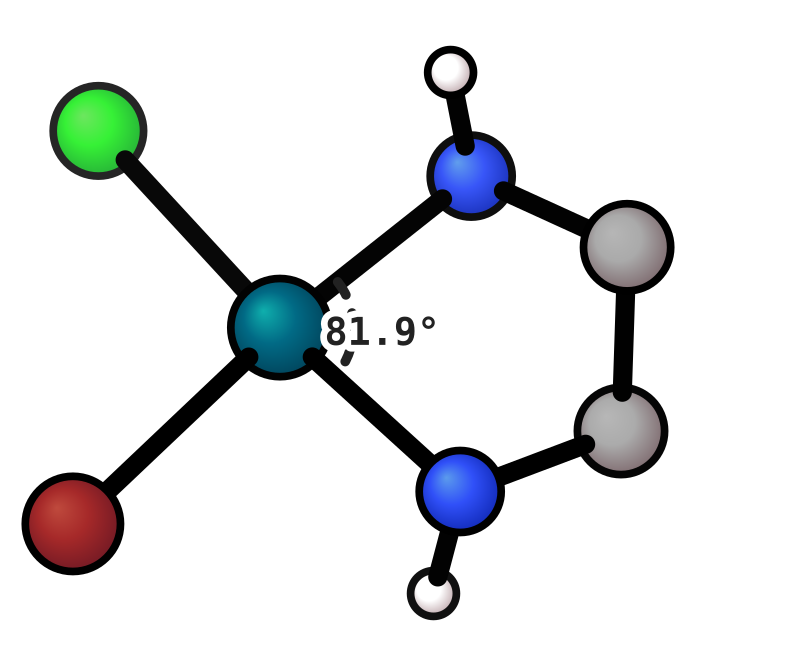

In [42]:
en = rx.metal("Br[Pd]1(Cl)NCCN1", "square_planar")  # the NCCN ring pins both N to Pd
iso = en.select(label="cis")
ens = rx.embed(iso).mc(preset="rapid").prune()
nn = [d for d in iso.donors if ens.mol.GetAtomWithIdx(d).GetSymbol() == "N"]
print(f"{len(ens)} conformers | en bite N-Pd-N = {ens.measure((nn[0], iso.metal, nn[1]))['mean']:.0f}°")
p = xyz(ens)
xyzrender.render(p, no_hy=True, labels=[f"{nn[0] + 1} {iso.metal + 1} {nn[1] + 1} a"])  # label the chelate bite angle

## Vacant sites — a coordination pocket

Name a geometry with **more vertices than donors** and the empty vertex is left as a pocket (`·` in the arrangement) for a substrate to bind later. A 3-donor Pd in a square-planar field leaves one site open.

rxembed | metal[square_planar]: 4 sites, 3 donors -> 1 vacant site(s) (coordination pocket)
rxembed | embed[square_planar cis]: 37 seeds
rxembed | mc: preset='rapid' on a constrained system under-samples (pose-mode is rotor-only); 'ensemble' (the default) is recommended for a constrained run
rxembed | mc: +1 (openconf 'rapid', pose-constrained around seeds; total 38)
rxembed | prune[rmsd]: 38 -> 6  (merged 32 near-duplicates; see .duplicates())


  [0] square_planar      cis     N2 Cl4 Cl5 ·
  [1] square_planar      trans   N2 Cl5 · Cl4


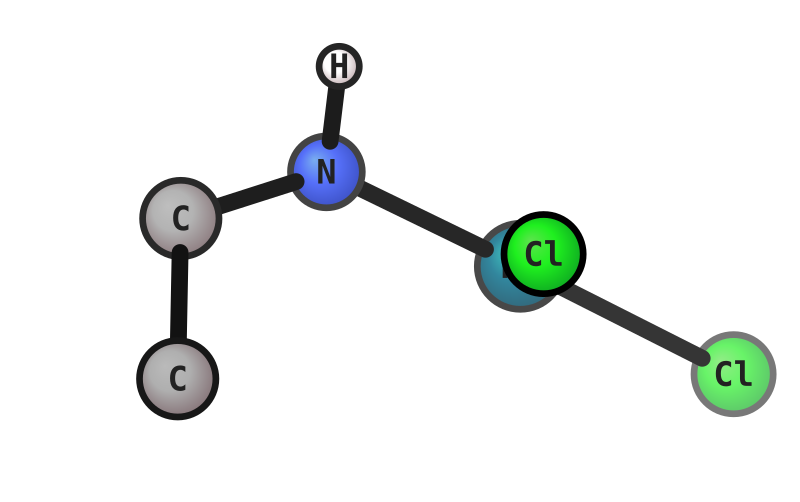

In [43]:
pocket = rx.metal("CCN[Pd](Cl)Cl", "square_planar")  # N + 2 Cl = 3 donors, 4 vertices
pocket.summary()  # '·' marks the vacant coordination site
iso = pocket.select(label="cis")
ens = rx.embed(iso).mc(preset="rapid").prune()
xyzrender.render(xyz(ens), no_hy=True, idx="s")  # the '·' vacancy sits opposite the lone Cl

## A real metal TS — reacting core frozen, spectator ferrocene held

A **bimetallic** Mn/Fe transition state: H₂ activation at Mn (H–H breaking, Mn–H / substrate N–H, O–H forming), with a *spectator* ferrocene. Freeze the reacting core — grafted back to **0.000 Å** on every pose while the periphery is searched; both metals restored. Here `ts_bonds=` is genuinely correct (real forming/breaking bonds), labelled with their live lengths — note the ~0.86 Å H–H being cleaved.

rxembed | embed: 3 seeds (78 atoms, 7 fragments, 88 constraints)
rxembed | mc: preset='rapid' on a constrained system under-samples (pose-mode is rotor-only); 'ensemble' (the default) is recommended for a constrained run


metals: [(0, 'Fe'), (1, 'Mn')]


rxembed | mc: +5 (openconf 'rapid', pose-constrained around seeds; total 8)
rxembed | minimize: stereo={'planar': 'preserve', 'default': 'free'} kept 7/8 (matched the input handedness)
rxembed | prune[rmsd]: 7 -> 6  (merged 1 near-duplicates; see .duplicates())
no bond between atoms 65 and 67 - placing label at midpoint
no bond between atoms 2 and 65 - placing label at midpoint


6 conformers | reacting core held to 0.0000 Å | metals: ['Fe', 'Mn']


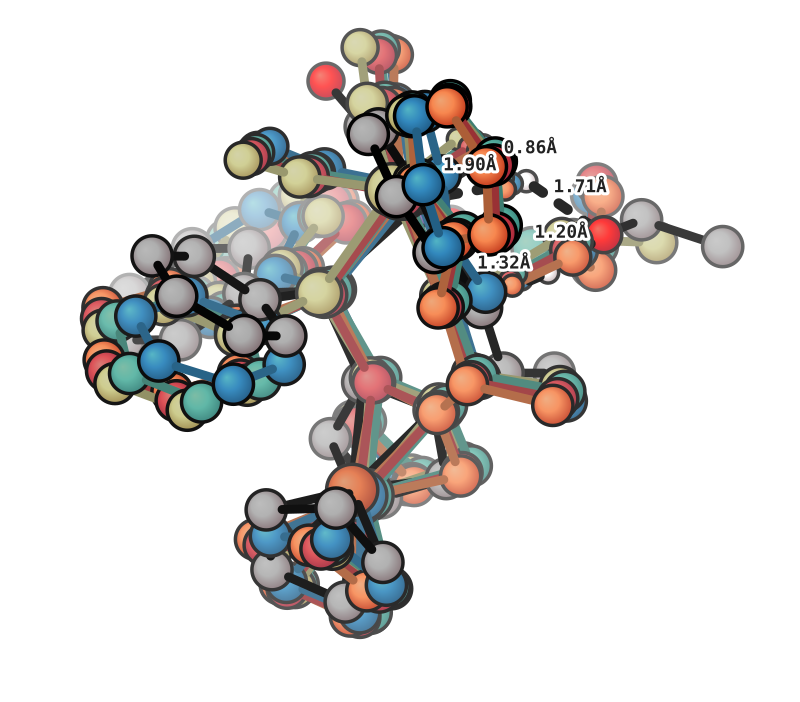

In [44]:
mn = "structures/mn-h2.xyz"
rc = [1, 5, 63, 64, 65, 66]  # reacting-core atoms (from a graphrc trajectory in practice)
bonds = [(5, 65), (64, 66), (1, 64), (65, 66), (63, 64)]  # forming / breaking bonds held during embed
Pin = _xyz_to_mol(mn, 0).GetConformer().GetPositions()
print("metals:", [(i, _xyz_to_mol(mn, 0).GetAtomWithIdx(i).GetSymbol()) for i in metal_indices(_xyz_to_mol(mn, 0))])
ens = rx.embed(mn, freeze=rc, n=3).mc(preset="rapid").prune()
drift = max(
    abs(T.GetBondLength(ens.mol.GetConformer(c), i, j) - float(np.linalg.norm(Pin[i] - Pin[j])))
    for c in ens.ids
    for i, j in bonds
)
print(
    f"{len(ens)} conformers | reacting core held to {drift:.4f} Å | "
    f"metals: {[ens.mol.GetAtomWithIdx(i).GetSymbol() for i in metal_indices(ens.mol)]}"
)
xyzrender.render(
    load(mxyz(ens), ensemble=True, ensemble_color="spectral"),
    no_hy=True,
    ts_bonds=[(i + 1, j + 1) for i, j in bonds],
    labels=[f"{i + 1} {j + 1} d" for i, j in bonds],
)

With the reacting core frozen, the **free** coordination sites around Mn are enumerated (mer/fac of the spectators). One arrangement (`fac1`) is geometrically infeasible and embeds to 0 conformers — honestly reported, not hidden — while **mer** embeds cleanly:

rxembed | metal: enumerating Mn1; holding 1 spectator metal(s) by 55 shape constraints
rxembed | metal: freezing 6 atom(s) at the input geometry; enumerating the free coordination sites around them
rxembed | metal[octahedral]: 2 frozen donor(s) pinned at input vertices; 24 free-site arrangement(s) to dedup


rxembed | embed[octahedral fac1]: 2 seeds
rxembed | mc: preset='rapid' on a constrained system under-samples (pose-mode is rotor-only); 'ensemble' (the default) is recommended for a constrained run
rxembed | mc: +2 (openconf 'rapid', pose-constrained around seeds; total 4)
rxembed | minimize: UFF could not relax this system (Invariant Violation
	bad direction in linearSearch
	Violation occurred on line 224 in file Code/Numerics/Optimizer/BFGSOpt.h
	Failed Expression: status >= 0
	RDKIT: 2026.03.3
	BOOST: 1_85
) — an untypable TS/hypervalent reacting core; keeping the embedded geometry (constraints biased, not stiffened)
rxembed | minimize: dropped 3 conformer(s) with a broken/clashing bond -> 1 kept
rxembed | minimize: stereo={'planar': 'preserve', 'default': 'free'} kept 0/1 (matched the input handedness)
rxembed | embed[octahedral fac2]: 2 seeds
rxembed | mc: preset='rapid' on a constrained system under-samples (pose-mode is rotor-only); 'ensemble' (the default) is recommended for a 

  fac1  :  0 confs | core held 0.0000 Å


rxembed | mc: +1 (openconf 'rapid', pose-constrained around seeds; total 3)
rxembed | minimize: UFF could not relax this system (Invariant Violation
	bad direction in linearSearch
	Violation occurred on line 224 in file Code/Numerics/Optimizer/BFGSOpt.h
	Failed Expression: status >= 0
	RDKIT: 2026.03.3
	BOOST: 1_85
) — an untypable TS/hypervalent reacting core; keeping the embedded geometry (constraints biased, not stiffened)
rxembed | minimize: dropped 2 conformer(s) with a broken/clashing bond -> 1 kept
rxembed | prune[rmsd]: 1 -> 1  (merged 0 near-duplicates; see .duplicates())
rxembed | embed[octahedral mer]: 2 seeds
rxembed | mc: preset='rapid' on a constrained system under-samples (pose-mode is rotor-only); 'ensemble' (the default) is recommended for a constrained run


  fac2  :  1 confs | core held 0.0000 Å


rxembed | mc: +1 (openconf 'rapid', pose-constrained around seeds; total 3)
rxembed | minimize: UFF could not relax this system (Invariant Violation
	bad direction in linearSearch
	Violation occurred on line 224 in file Code/Numerics/Optimizer/BFGSOpt.h
	Failed Expression: status >= 0
	RDKIT: 2026.03.3
	BOOST: 1_85
) — an untypable TS/hypervalent reacting core; keeping the embedded geometry (constraints biased, not stiffened)
rxembed | minimize: dropped 2 conformer(s) with a broken/clashing bond -> 1 kept
rxembed | prune[rmsd]: 1 -> 1  (merged 0 near-duplicates; see .duplicates())
rxembed | embed[octahedral mer]: 3 seeds
rxembed | mc: preset='rapid' on a constrained system under-samples (pose-mode is rotor-only); 'ensemble' (the default) is recommended for a constrained run


  mer   :  1 confs | core held 0.0000 Å


rxembed | mc: +5 (openconf 'rapid', pose-constrained around seeds; total 8)
rxembed | minimize: UFF could not relax this system (Invariant Violation
	bad direction in linearSearch
	Violation occurred on line 224 in file Code/Numerics/Optimizer/BFGSOpt.h
	Failed Expression: status >= 0
	RDKIT: 2026.03.3
	BOOST: 1_85
) — an untypable TS/hypervalent reacting core; keeping the embedded geometry (constraints biased, not stiffened)
rxembed | minimize: stereo={'planar': 'preserve', 'default': 'free'} kept 1/8 (matched the input handedness)
rxembed | prune[rmsd]: 1 -> 1  (merged 0 near-duplicates; see .duplicates())


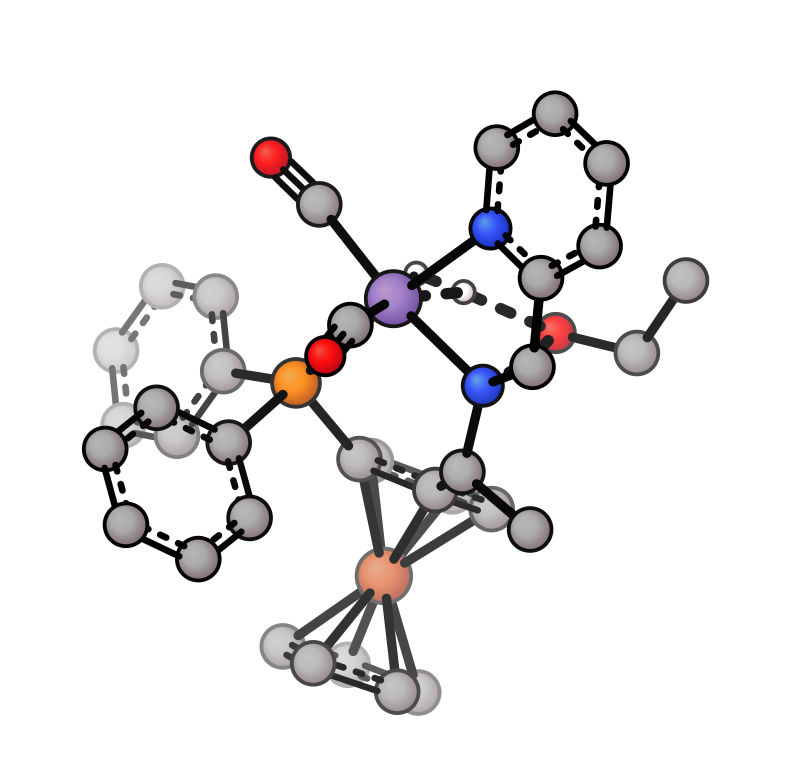

In [45]:
isos = rx.metal(mn, "octahedral", center="Mn", freeze=rc)
for iso in isos:
    e = rx.embed(iso, n=2).mc(preset="rapid").prune()
    d = max(
        (
            abs(T.GetBondLength(e.mol.GetConformer(c), i, j) - float(np.linalg.norm(Pin[i] - Pin[j])))
            for c in e.ids
            for i, j in bonds
        ),
        default=0.0,
    )
    print(f"  {iso.label:6s}: {len(e):2d} confs | core held {d:.4f} Å")
mer = rx.embed(isos.select(label="mer"), n=3).mc(preset="rapid").prune()
xyzrender.render(xyz(mer), no_hy=True, ts_bonds=[(i + 1, j + 1) for i, j in bonds])  # the mer isomer

The same frozen-TS machinery spans very different real organometallic TS (core held to 0.000 Å, every metal restored): **mn-h2** (H₂ activation, 78 atoms), **mn-hy** (a larger Mn hydride, 95 atoms), **ru-co** (a Ru carbonyl TS, 72 atoms).

In [46]:
META = {  # reacting core + forming/breaking bonds per TS (from graphrc trajectories in practice)
    "mn-h2": {"rc": [1, 5, 63, 64, 65, 66], "bonds": [(5, 65), (64, 66), (1, 64), (65, 66), (63, 64)], "natoms": 78},
    "mn-hy": {"rc": [1, 67, 77], "bonds": [(67, 77), (1, 67)], "natoms": 95},
    "ru-co": {"rc": [0, 3, 63, 64, 66], "bonds": [(0, 64), (64, 66), (0, 63), (3, 66)], "natoms": 72},
}
for name in ["mn-h2", "mn-hy", "ru-co"]:
    rc2 = META[name]["rc"]
    b2 = META[name]["bonds"]
    pin = _xyz_to_mol(f"structures/{name}.xyz", 0).GetConformer().GetPositions()
    e = rx.embed(f"structures/{name}.xyz", freeze=rc2, n=2).mc(preset="rapid").prune()
    drift = max(
        abs(T.GetBondLength(e.mol.GetConformer(c), i, j) - float(np.linalg.norm(pin[i] - pin[j])))
        for c in e.ids
        for i, j in b2
    )
    metals = [e.mol.GetAtomWithIdx(i).GetSymbol() for i in metal_indices(e.mol)]
    print(f"  {name:6s}: {META[name]['natoms']:3d} atoms | {len(e):2d} confs | core held {drift:.4f} Å | {metals}")

rxembed | embed: 2 seeds (78 atoms, 7 fragments, 88 constraints)
rxembed | mc: preset='rapid' on a constrained system under-samples (pose-mode is rotor-only); 'ensemble' (the default) is recommended for a constrained run
rxembed | mc: +2 (openconf 'rapid', pose-constrained around seeds; total 4)
rxembed | prune[rmsd]: 4 -> 4  (merged 0 near-duplicates; see .duplicates())


  mn-h2 :  78 atoms |  4 confs | core held 0.0000 Å | ['Fe', 'Mn']


rxembed | embed: 2 seeds (95 atoms, 8 fragments, 78 constraints)
rxembed | mc: preset='rapid' on a constrained system under-samples (pose-mode is rotor-only); 'ensemble' (the default) is recommended for a constrained run
rxembed | mc: +1 (openconf 'rapid', pose-constrained around seeds; total 3)
rxembed | prune[rmsd]: 3 -> 3  (merged 0 near-duplicates; see .duplicates())
rxembed | embed: 2 seeds (72 atoms, 5 fragments, 32 constraints)


  mn-hy :  95 atoms |  3 confs | core held 0.0000 Å | ['Fe', 'Mn']


rxembed | mc: preset='rapid' on a constrained system under-samples (pose-mode is rotor-only); 'ensemble' (the default) is recommended for a constrained run
rxembed | mc: +1 (openconf 'rapid', pose-constrained around seeds; total 3)
rxembed | prune[rmsd]: 3 -> 2  (merged 1 near-duplicates; see .duplicates())


  ru-co :  72 atoms |  2 confs | core held 0.0000 Å | ['Ru']


## Seating a substrate — and switching its binding mode

Reach a substrate donor into the vacant site with `coordinate=`. A Pt(amine)Cl₂ has one open site; seat an acetone carbonyl O there (a coordinative Pt–O bond, drawn dotted + labelled).

rxembed | metal[square_planar]: 4 sites, 3 donors -> 1 vacant site(s) (coordination pocket)
rxembed | embed[square_planar cis coord@[7]]: 3 seeds
rxembed | mc: preset='rapid' on a constrained system under-samples (pose-mode is rotor-only); 'ensemble' (the default) is recommended for a constrained run
rxembed | mc: +1 (openconf 'rapid', pose-constrained around seeds; total 4)
rxembed | prune[rmsd]: 4 -> 1  (merged 3 near-duplicates; see .duplicates())


acetone O seated: Pt-O = 2.19 Å  (1 confs)


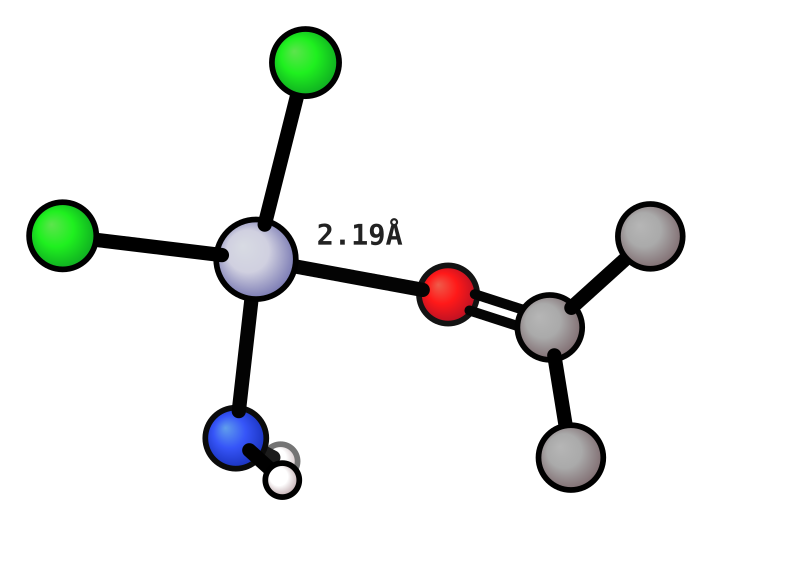

In [47]:
isos = rx.metal("N[Pt](Cl)Cl.CC(C)=O", "square_planar")  # 3 donors + acetone -> one vacant site
iso = isos.select(label="cis")
O = next(a.GetIdx() for a in iso.mol.GetAtoms() if a.GetSymbol() == "O")
seated = rx.embed(iso, coordinate=O, n=3).mc(preset="rapid").prune()
print(f"acetone O seated: Pt-O = {seated.measure((iso.metal, O))['mean']:.2f} Å  ({len(seated)} confs)")
xyzrender.render(xyz(seated), no_hy=True, labels=[f"{iso.metal + 1} {O + 1} d"])  # label the new Pt-O coordinative bond

**Switching the binding mode:** the same substrate can grip *bifunctionally* — the O coordinated to Pt **and** an amine N–H···O hydrogen bond held at the same time. Two contacts, one pose (both dotted, both labelled).

rxembed | embed[square_planar cis coord@[7]]: 3 seeds
rxembed | mc: preset='rapid' on a constrained system under-samples (pose-mode is rotor-only); 'ensemble' (the default) is recommended for a constrained run
rxembed | mc: +1 (openconf 'rapid', pose-constrained around seeds; total 4)
rxembed | constraint NOT held: d(7,8) = 2.93, target 1.60-2.20
rxembed | constraint NOT held: angle(0,8,7) = 134.3, target 140.0-180.0
rxembed | prune[rmsd]: 4 -> 2  (merged 2 near-duplicates; see .duplicates())
no bond between atoms 9 and 8 - placing label at midpoint


bifunctional: Pt-O 2.20 Å + H-O 2.93 Å, N-H-O 134°


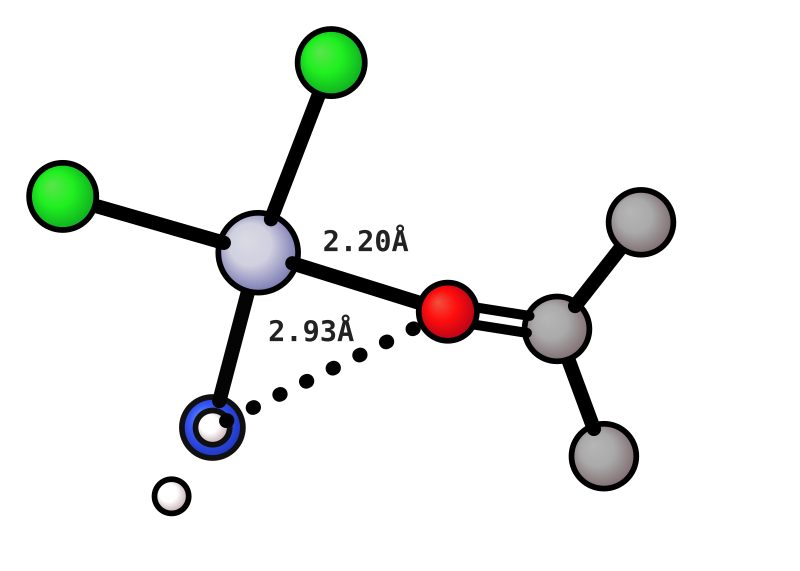

In [48]:
N = next(d for d in iso.donors if iso.mol.GetAtomWithIdx(d).GetSymbol() == "N")
H = next(n.GetIdx() for n in iso.mol.GetAtomWithIdx(N).GetNeighbors() if n.GetAtomicNum() == 1)
grip = rx.Contact(distances={(min(H, O), max(H, O)): (1.6, 2.2)}, angles={(N, H, O): (140.0, 180.0)}, label="NH..O")
bi = rx.embed(iso, coordinate=O, contacts=grip, n=3).mc(preset="rapid").prune()
print(
    f"bifunctional: Pt-O {bi.measure((iso.metal, O))['mean']:.2f} Å + H-O {bi.measure((H, O))['mean']:.2f} Å, "
    f"N-H-O {bi.measure((N, H, O))['mean']:.0f}°"
)
xyzrender.render(
    xyz(bi),
    no_hy=True,
    nci_bonds=[(H + 1, O + 1)],  # only the H...O is an NCI (dotted); Pt-O is a normal bond
    labels=[f"{iso.metal + 1} {O + 1} d", f"{H + 1} {O + 1} d"],
)